Перечень функций:

In [1]:
def edit_names_columns(df):
    
    """Переводит имена столбцов в нижний регистр, удаляет пробелы в начале и конце имени, 
    заменяет пробелы на знак нижнего подчеркивания"""
    
    df.columns = [x.lower().strip().replace(' ', '_') for x in df.columns]
    print(df.columns)

In [2]:
def primary_info(df):
    
    '''Расчитывает количество дубликатов и пропусков в данных, 
    выводит информацию о количественных и категориальных данных'''
    
    data = df.drop('id', axis=1)
    print(f'Количество пропусков:\n{df.isna().sum()}\n')
    print(f'Количество дубликатов: {df.duplicated().sum()}\n')
    print(f'Количественные признаки: {data.select_dtypes(include=[np.number]).columns.tolist()}\n')
    print(f'Категориальные признаки: {data.select_dtypes(exclude=[np.number]).columns.tolist()}\n')

In [3]:
def plot_num_columns(df):
    
    """Строит гистрограмму и ящик с усами по количественным признакам."""
    
    names_num_columns = df.drop('id', axis=1).select_dtypes(include=[np.number]).columns.tolist()
    for name_column in names_num_columns:
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'Распределение признака {name_column}', fontsize=16)
        
        sns.histplot(data=df, x=name_column, ax=ax1)
        ax1.set_title(f'Гистограмма признака {name_column}')
        ax1.set_ylabel('Количество')
        
        sns.boxplot(data=df, x=name_column, ax=ax2)
        ax2.set_title(f'Ящик с усами признака {name_column}')
        
        plt.show()

In [4]:
def plot_cat_columns(df):
    
    """Строит графики countplot по категориальным признакам."""
    
    names_cat_columns = df.select_dtypes(exclude = [np.number]).columns.tolist()
    
    while len(names_cat_columns) > 0:
        plt.figure(figsize=(15, 5))
        for i in [1, 2]:
            if len(names_cat_columns) > 0:
                name_column = names_cat_columns.pop(0)
                plt.subplot(1, 2, i)
                sns.countplot(data=df, x=name_column, orient='h')
                plt.title(f'Распределение признака {name_column}')
                plt.ylabel('Количество')
                locs, labels = plt.xticks()
                plt.setp(labels, rotation=60)
            else:
                continue
        plt.show

# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 10 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

## Загрузка и подготовка данных

Загрузим и изучим данные и необходимые библиотеки

In [5]:
!pip install -U scikit-learn -q
!pip install shap -q

In [6]:
pip install phik -q

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install shap -q

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import percentileofscore
from scipy import stats
from phik import phik_matrix
from phik.report import plot_correlation_matrix
from sklearn.dummy import DummyClassifier
from phik.report import plot_correlation_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, recall_score, precision_score, RocCurveDisplay, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer

In [9]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [10]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [11]:
try:
    geo_data = pd.read_csv('/datasets/geo_data_0.csv', sep=',', decimal='.')
except:
    geo_data = pd.read_csv(r'C:\Users\user\Desktop\файлы для проектов\geo_data_0.csv', sep=',', decimal='.')
    
geo_data.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [12]:
try:
    geo_data_1 = pd.read_csv('/datasets/geo_data_1.csv', sep=',', decimal='.')
except:
    geo_data_1 = pd.read_csv(r'C:\Users\user\Desktop\файлы для проектов\geo_data_1.csv', sep=',', decimal='.')
    
geo_data_1.head()

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [13]:
try:
    geo_data_2 = pd.read_csv('/datasets/geo_data_2.csv', sep=',', decimal='.')
except:
    geo_data_2 = pd.read_csv(r'C:\Users\user\Desktop\файлы для проектов\geo_data_2.csv', sep=',', decimal='.')
    
geo_data_1.head()

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [14]:
geo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [15]:
geo_data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [16]:
geo_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [17]:
# Отредактируем имена столбцов
edit_names_columns(geo_data)

Index(['id', 'f0', 'f1', 'f2', 'product'], dtype='object')


In [18]:
# Отредактируем имена столбцов
edit_names_columns(geo_data_1)

Index(['id', 'f0', 'f1', 'f2', 'product'], dtype='object')


In [19]:
# Отредактируем имена столбцов
edit_names_columns(geo_data_2)

Index(['id', 'f0', 'f1', 'f2', 'product'], dtype='object')


In [20]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(geo_data)

Количество пропусков:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['f0', 'f1', 'f2', 'product']

Категориальные признаки: []



In [21]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(geo_data_1)

Количество пропусков:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['f0', 'f1', 'f2', 'product']

Категориальные признаки: []



In [22]:
# Проверим наличие пропусков и дубликатов, посмотрим на количественные и категориальные данные
primary_info(geo_data_2)

Количество пропусков:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Количество дубликатов: 0

Количественные признаки: ['f0', 'f1', 'f2', 'product']

Категориальные признаки: []



In [23]:
# Проверим данные в столбце id на неявные дубликаты
geo_data['id'].sort_values().unique()

array(['006OJ', '009eY', '00AfQ', ..., 'zztWK', 'zzyhQ', 'zzzLH'],
      dtype=object)

In [24]:
# Проверим данные в столбце id на неявные дубликаты
geo_data_1['id'].sort_values().unique()

array(['0022J', '003Gl', '003Vx', ..., 'zzv4E', 'zzy2c', 'zzzvI'],
      dtype=object)

In [25]:
# Проверим данные в столбце id на неявные дубликаты
geo_data_2['id'].sort_values().unique()

array(['009Gl', '00AuD', '00CaL', ..., 'zzqqy', 'zzsKd', 'zzz9h'],
      dtype=object)

Исследуем все признаки и сделаем выводы о том, как их нужно подготовить.

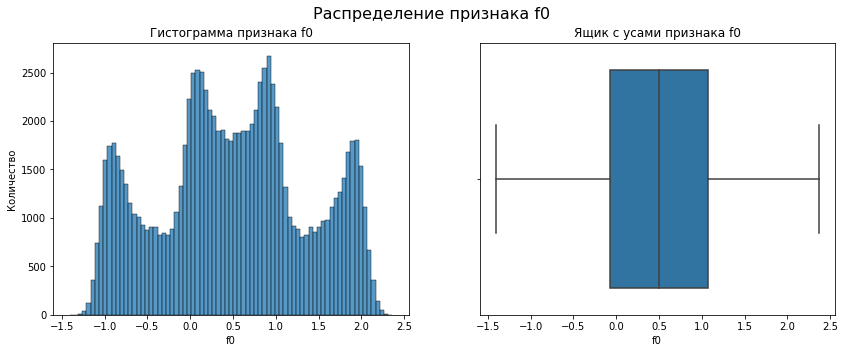

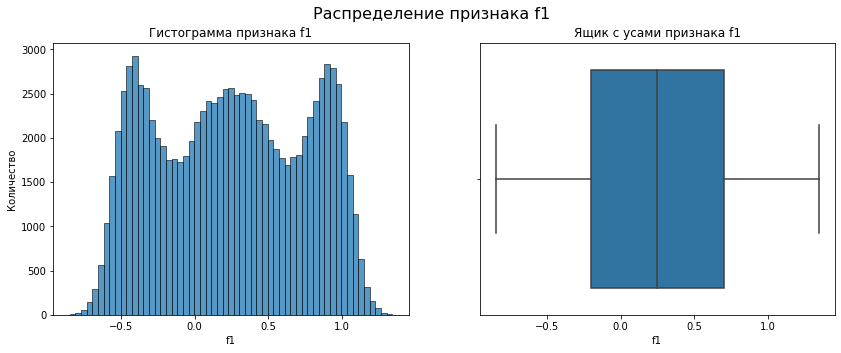

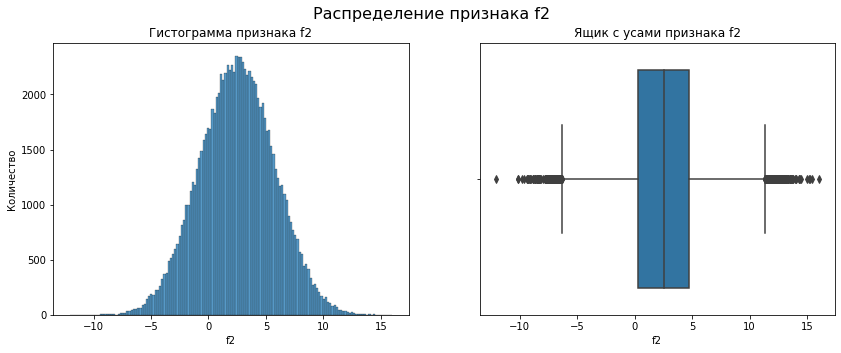

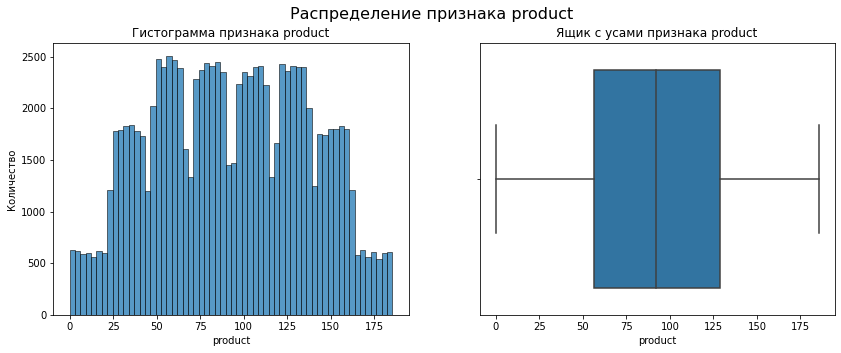

In [26]:
# Посмотрим на распределение количественных признаков
plot_num_columns(geo_data)

Согласно гистограмме только у признака 'f2' нормальное распределение

Категориальных признаков нет.

In [27]:
# указание файла для проверки
numerical_data = geo_data.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца f0: 0.2220607993875393
Значение теста Лиллиэфорса для столбца f0: 0.0
Статистика теста Лиллиэфорса для столбца f1: 0.26021298669738524
Значение теста Лиллиэфорса для столбца f1: 0.0
Статистика теста Лиллиэфорса для столбца f2: 0.5544414649301712
Значение теста Лиллиэфорса для столбца f2: 0.0
Статистика теста Лиллиэфорса для столбца product: 0.9927706882920027
Значение теста Лиллиэфорса для столбца product: 0.0


В данном случае, все значения теста Лиллиэфорса для столбцов f0, f1, f2 и product равны 0.0, что может указывать на то, что соответствующие данные имеют нормальное распределение.

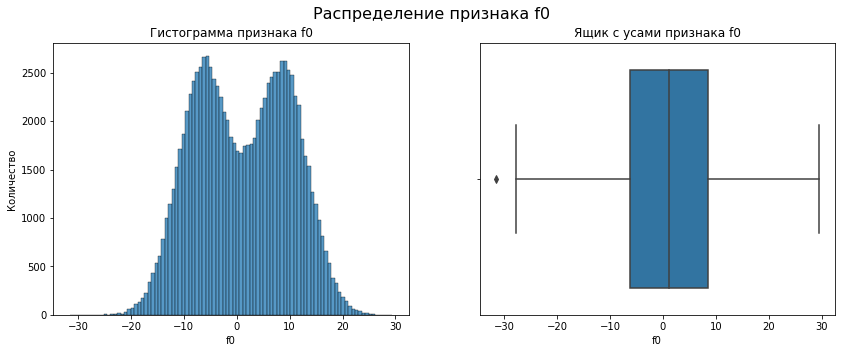

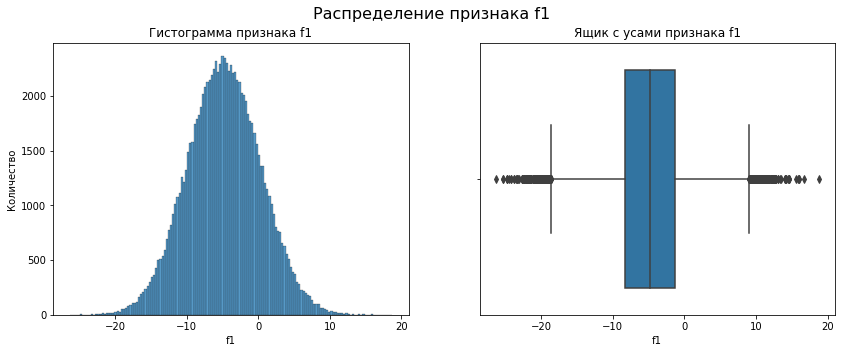

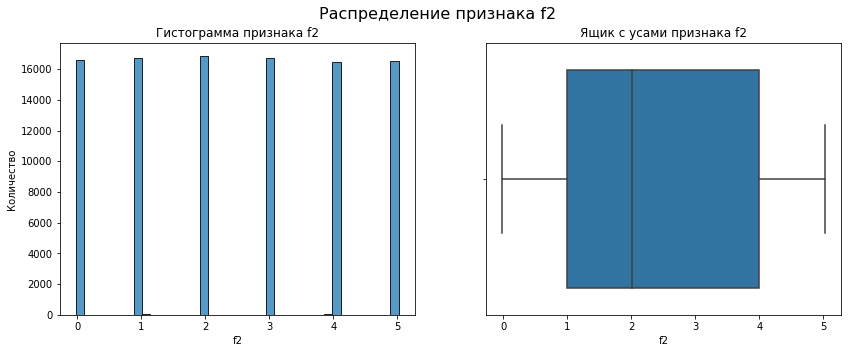

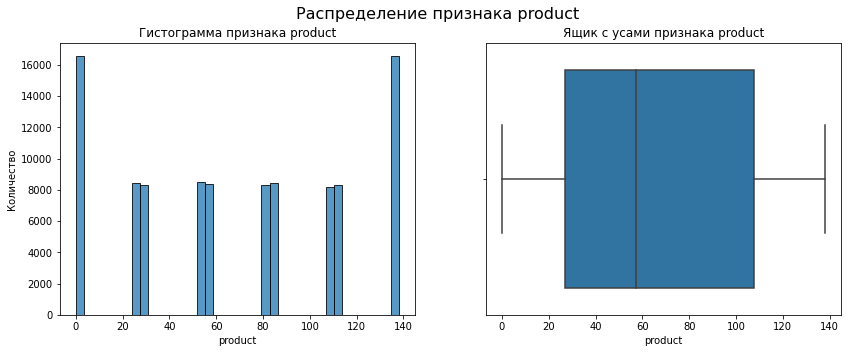

In [28]:
# Посмотрим на распределение количественных признаков
plot_num_columns(geo_data_1)

Согласно гистограмме только у признака 'f1' нормальное распределение. Категориальных признаков нет.

In [29]:
# указание файла для проверки
numerical_data = geo_data_1.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца f0: 0.4582363919882826
Значение теста Лиллиэфорса для столбца f0: 0.0
Статистика теста Лиллиэфорса для столбца f1: 0.6853550799694432
Значение теста Лиллиэфорса для столбца f1: 0.0
Статистика теста Лиллиэфорса для столбца f2: 0.6718203692021074
Значение теста Лиллиэфорса для столбца f2: 0.0
Статистика теста Лиллиэфорса для столбца product: 0.9169113410109595
Значение теста Лиллиэфорса для столбца product: 0.0


Значения теста Лиллиэфорса для всех столбцов равны 0.0, что может указывать на то, что соответствующие данные имеют нормальное распределение.

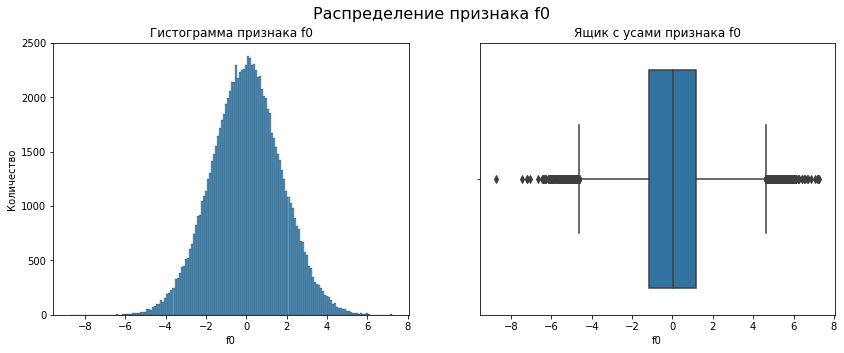

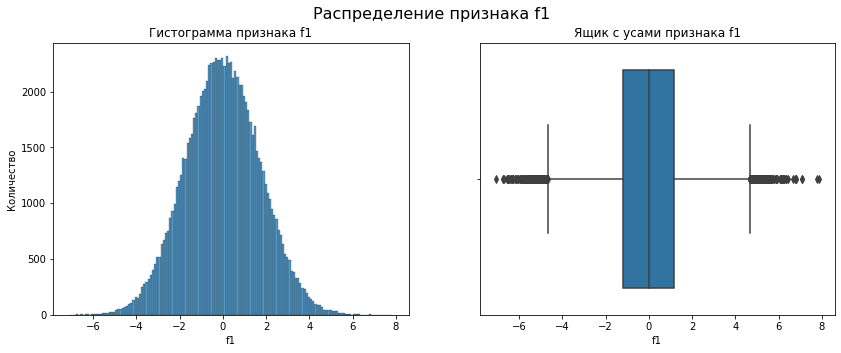

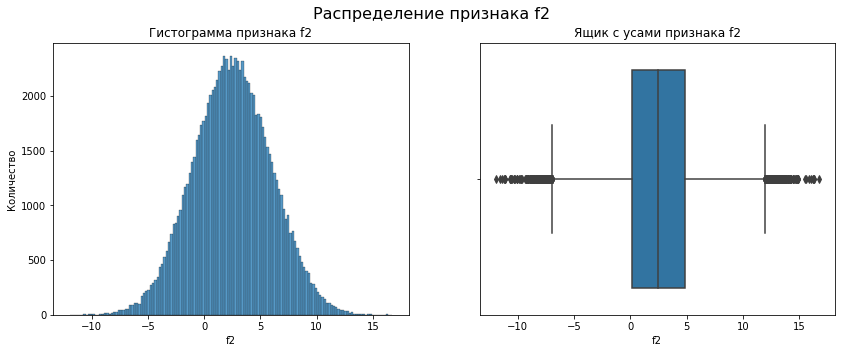

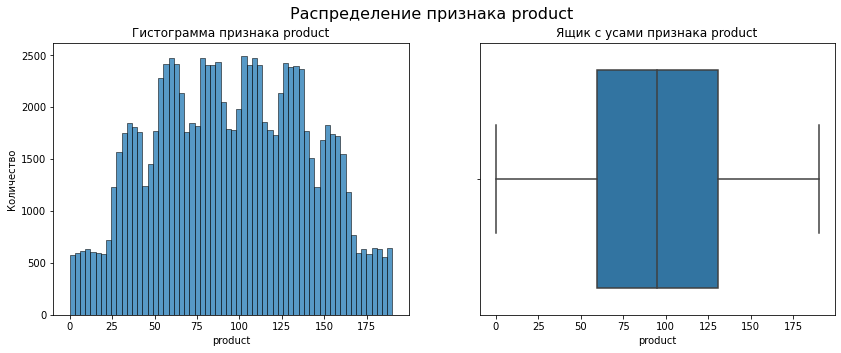

In [30]:
# Посмотрим на распределение количественных признаков
plot_num_columns(geo_data_2)

Согласно гистограмме только у признака 'f1', 'f2' и 'f0' нормальное распределение. Категориальных признаков нет.

In [31]:
# указание файла для проверки
numerical_data = geo_data_2.select_dtypes(include=[np.number])

# Проведение теста Лиллиэфорса для каждого числового столбца отдельно
kstest_results = []
for column in numerical_data.columns:
    lilliefors_stat, lilliefors_p_value = stats.kstest(numerical_data[column], 'norm')
    kstest_results.append((column, lilliefors_stat, lilliefors_p_value))

# Отображение результатов
for result in kstest_results:
    print(f"Статистика теста Лиллиэфорса для столбца {result[0]}:", result[1])
    print(f"Значение теста Лиллиэфорса для столбца {result[0]}:", result[2])

Статистика теста Лиллиэфорса для столбца f0: 0.1291722886600322
Значение теста Лиллиэфорса для столбца f0: 0.0
Статистика теста Лиллиэфорса для столбца f1: 0.1309603970746873
Значение теста Лиллиэфорса для столбца f1: 0.0
Статистика теста Лиллиэфорса для столбца f2: 0.546187738210129
Значение теста Лиллиэфорса для столбца f2: 0.0
Статистика теста Лиллиэфорса для столбца product: 0.9932855757485204
Значение теста Лиллиэфорса для столбца product: 0.0


Значения теста Лиллиэфорса для всех столбцов составляют 0.0, что может указывать на то, что соответствующие данные имеют нормальное распределение.

Проверим коррекляционный анализ

Файл geo_data

In [32]:
names_num_columns = geo_data.drop('id', axis=1).select_dtypes(include=[np.number]).columns.tolist()
names_num_columns

['f0', 'f1', 'f2', 'product']

In [33]:
names_cat_columns = geo_data.select_dtypes(exclude=[np.number]).columns.tolist()
names_cat_columns

['id']

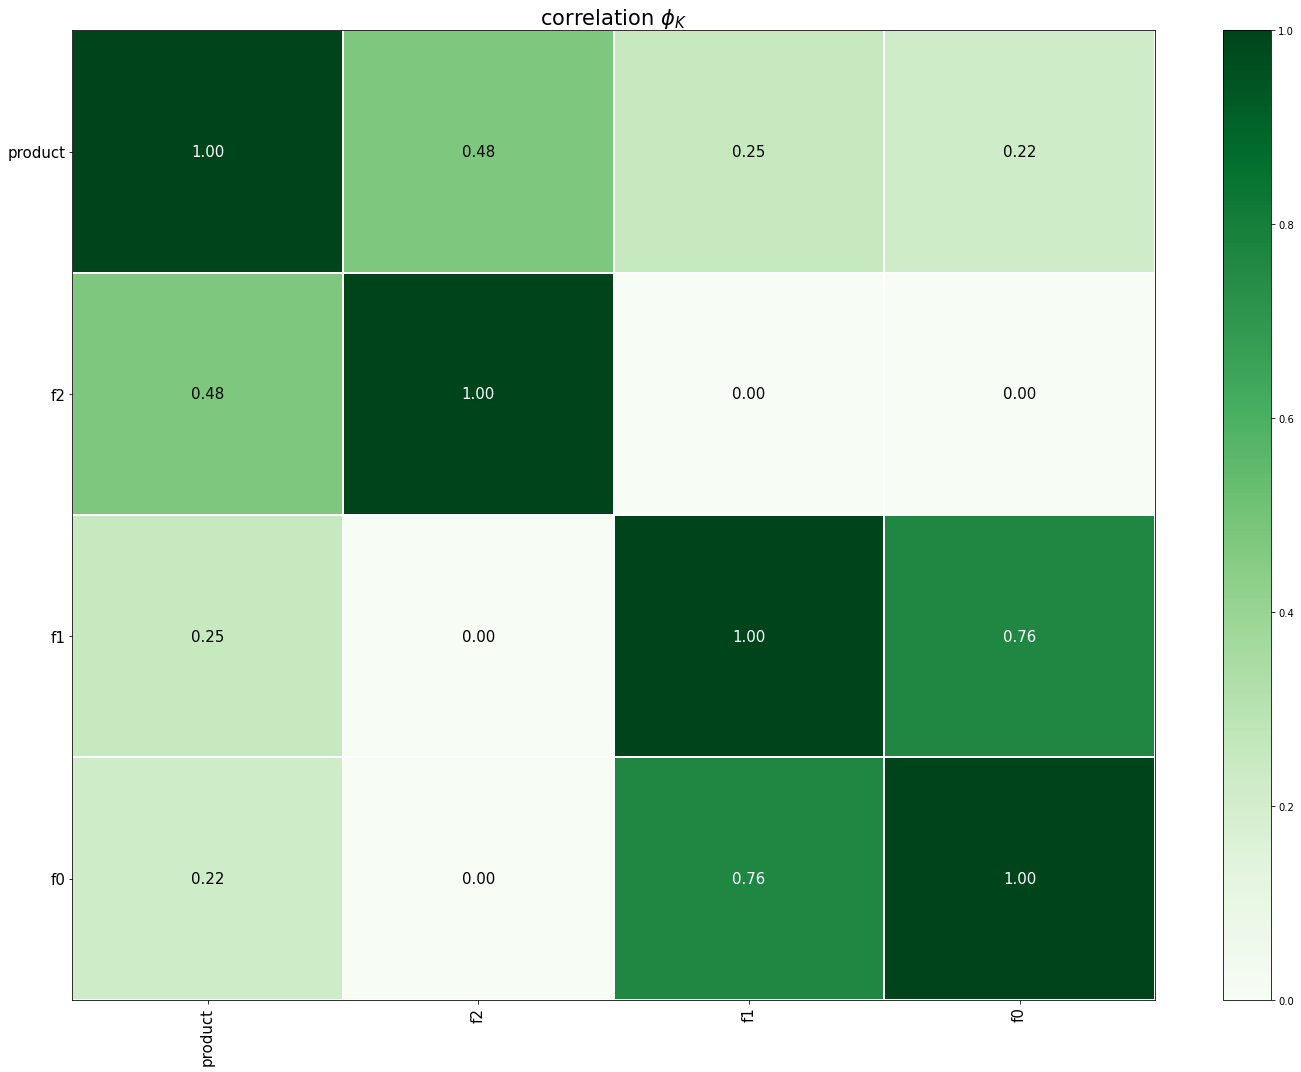

In [34]:
phik_overview = phik_matrix(geo_data.drop('id', axis=1), interval_cols=names_num_columns)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

f1 имеет высокую коррекляцию с f0 (0,76).

Проверим на мультиколлениарность

               f0        f1        f2   product
f0       1.000000 -0.440723 -0.003153  0.143536
f1      -0.440723  1.000000  0.001724 -0.192356
f2      -0.003153  0.001724  1.000000  0.483663
product  0.143536 -0.192356  0.483663  1.000000


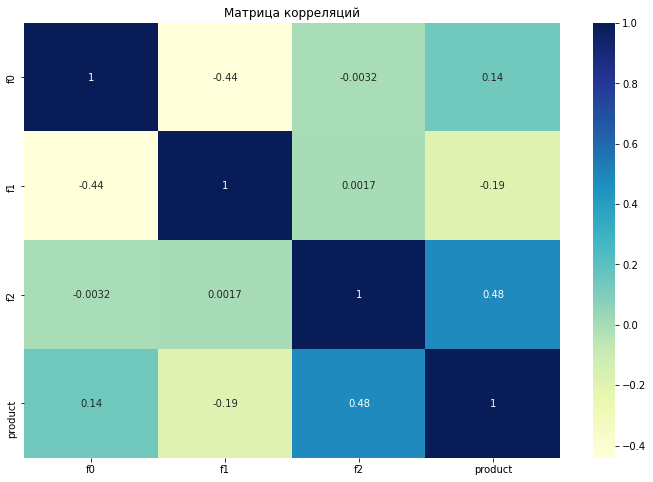

In [35]:
# Вычисление коэффициентов корреляции Пирсона
correlation_matrix = geo_data.corr()

# Вывод матрицы корреляции
print(correlation_matrix)

# Визуализация матрицы корреляций
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu")
plt.title('Матрица корреляций')
plt.show()

Для столбцов f0 и f1 коэффициент корреляции составляет -0.440723, что указывает на некоторую отрицательную линейную взаимосвязь между этими двумя переменными.
Для столбцов f0 и product коэффициент корреляции составляет 0.143536, что указывает на низкую положительную линейную связь.
Для столбцов f1 и product коэффициент корреляции составляет -0.192356, также указывая на некоторую отрицательную линейную взаимосвязь.

Файл geo_data_1

In [36]:
names_num_columns = geo_data_1.drop('id', axis=1).select_dtypes(include=[np.number]).columns.tolist()
names_num_columns

['f0', 'f1', 'f2', 'product']

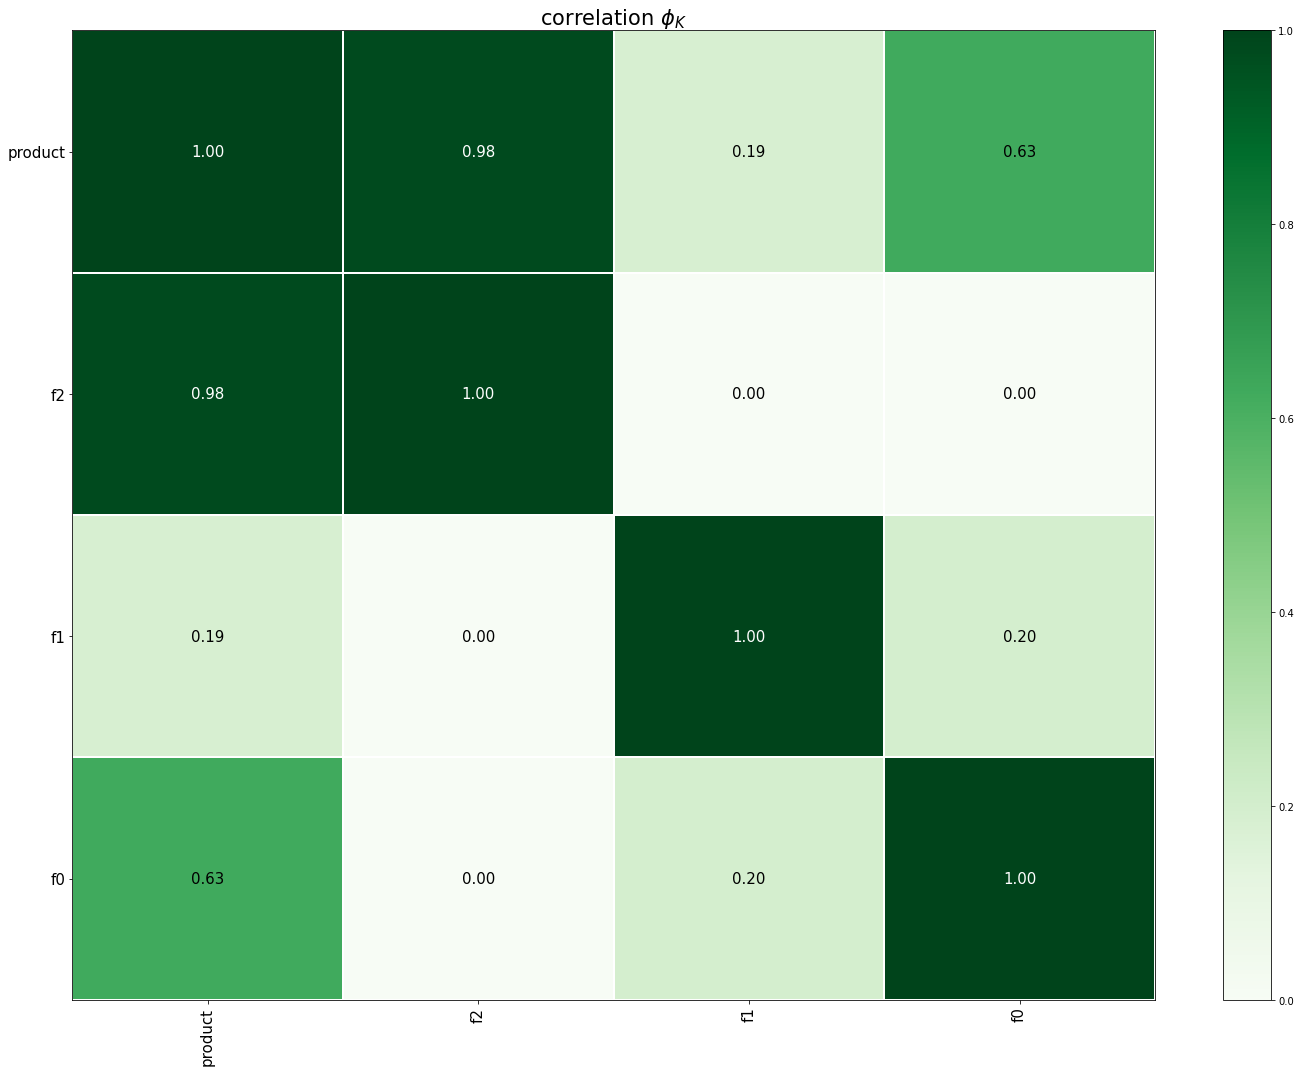

In [37]:
phik_overview = phik_matrix(geo_data_1.drop('id', axis=1), interval_cols=names_num_columns)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

У f2 очень высокая корреляция с product (0,98). f0 с product корреляция 0.63.

Проверим на мультиколлениарность

               f0        f1        f2   product
f0       1.000000  0.182287 -0.001777 -0.030491
f1       0.182287  1.000000 -0.002595 -0.010155
f2      -0.001777 -0.002595  1.000000  0.999397
product -0.030491 -0.010155  0.999397  1.000000


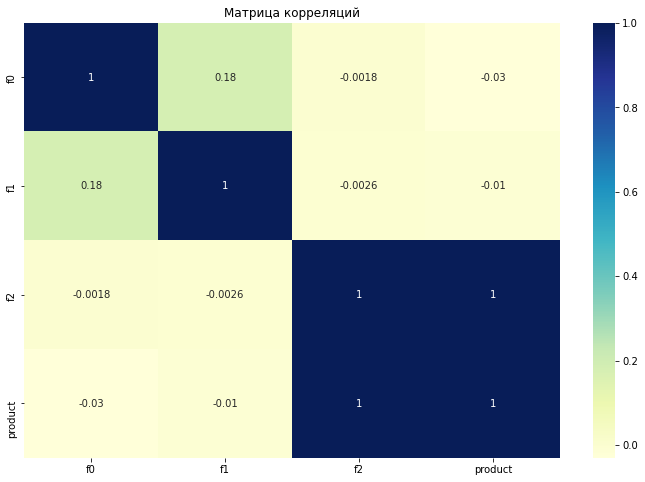

In [38]:
# Вычисление коэффициентов корреляции Пирсона
correlation_matrix = geo_data_1.corr()

# Вывод матрицы корреляции
print(correlation_matrix)

# Визуализация матрицы корреляций
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu")
plt.title('Матрица корреляций')
plt.show()

Из корреляционной матрицы видно, что коэффициент корреляции между столбцами f2 и product составляет 0.999397, что указывает на очень сильную положительную линейную корреляцию практически равную 1. Это говорит о том, что столбцы f2 и product сильно связаны, что подтверждает их почти полное линейное взаимосвязь.

Также стоит отметить, что коэффициент корреляции между столбцами f0 и f1 составляет 0.182287, что указывает на отсутствие сильной линейной зависимости между этими столбцами.

Однако, несмотря на сильную корреляцию между столбцами f2 и product, важно отметить, что значение 1 указывает на наличие линейной зависимости, но не обязательно на причинно-следственную связь. Также возможно, что эти столбцы дублируют или представляют почти идентичную информацию.

Поэтому рекомендуется провести дополнительный анализ этих переменных, возможно, исключить один из них из модели, чтобы избежать проблемы мультиколлинеарности, если они представляют схожую информацию.

Файл geo_data_2

In [39]:
names_num_columns = geo_data_2.drop('id', axis=1).select_dtypes(include=[np.number]).columns.tolist()
names_num_columns

['f0', 'f1', 'f2', 'product']

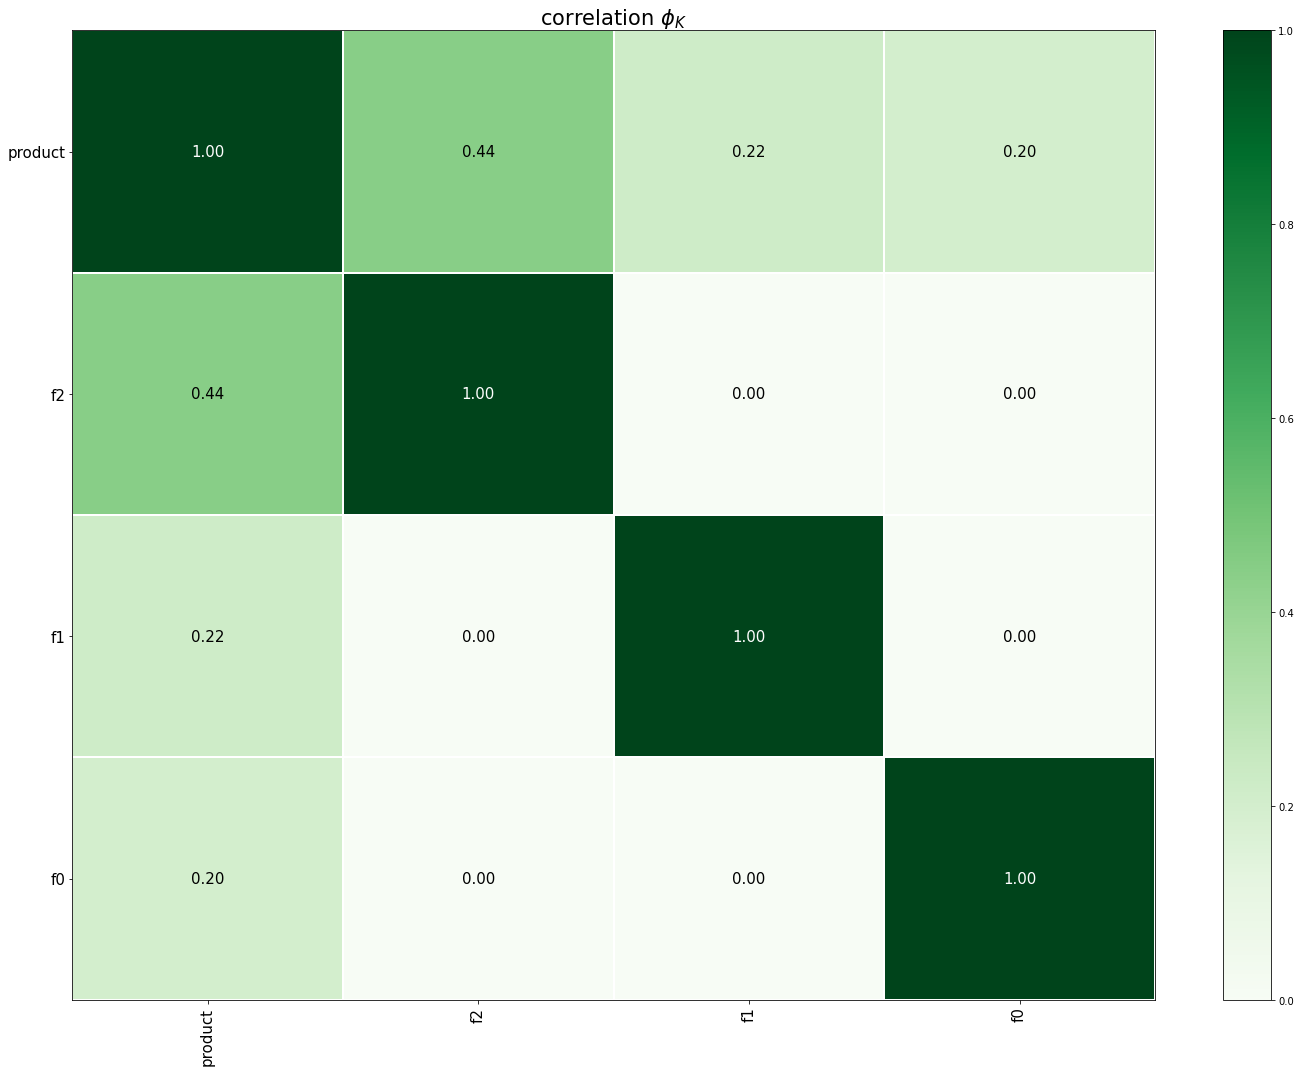

In [40]:
phik_overview = phik_matrix(geo_data_2.drop('id', axis=1), interval_cols=names_num_columns)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Корреляция product с f2 ниже средней (0,44).

Проверим на мультиколлениарность

               f0        f1        f2   product
f0       1.000000  0.000528 -0.000448 -0.001987
f1       0.000528  1.000000  0.000779 -0.001012
f2      -0.000448  0.000779  1.000000  0.445871
product -0.001987 -0.001012  0.445871  1.000000


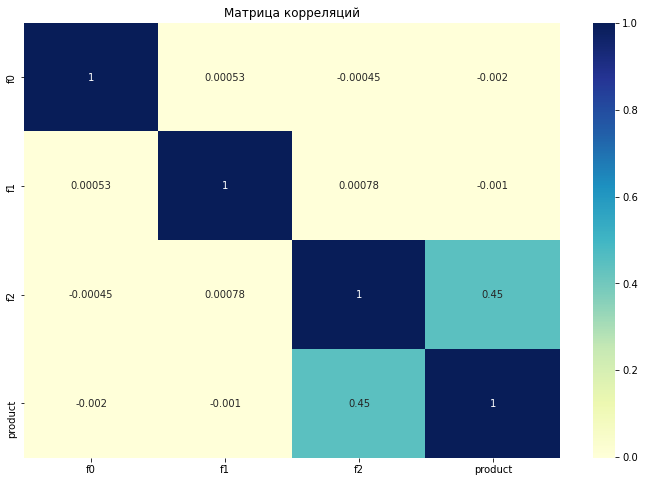

In [41]:
# Вычисление коэффициентов корреляции Пирсона
correlation_matrix = geo_data_2.corr()

# Вывод матрицы корреляции
print(correlation_matrix)

# Визуализация матрицы корреляций
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="YlGnBu")
plt.title('Матрица корреляций')
plt.show()

Из корреляционной матрицы видно, что коэффициент корреляции между столбцами f2 и product составляет 0.445871, что указывает на некоторую положительную линейную корреляцию между ними. Однако этот уровень корреляции может трактоваться как умеренный.

Коэффициенты корреляции между столбцами f0, f1 и product крайне близки к нулю, что указывает на отсутствие сильной линейной зависимости между ними.

##### Вывод по корреляционному анализу файлов:

  Файл "geo_data":

  Данные в столбцах f0 и f1 имеют высокую корреляцию (0,76), что говорит о сильной положительной линейной связи между этими переменными.
Коэффициент корреляции между столбцом f0 и переменной "product" составляет 0,143536, указывая на низкую положительную линейную связь.
Коэффициент корреляции между столбцом f1 и переменной "product" составляет -0,192356, указывая на некоторую отрицательную линейную взаимосвязь.
Проверка на мультиколлинеарность показала, что между столбцами f0 и f1 существует некоторая отрицательная линейная взаимосвязь, а между столбцами f0, f1 и "product" отсутствует сильная линейная зависимость.

  Файл "geo_data_1":

  Существует очень высокая корреляция между столбцом f2 и переменной "product" (0,98), указывающая на сильную положительную линейную связь между этими переменными.
Коэффициент корреляции между столбцом f0 и "product" составляет 0,63, что также указывает на высокую положительную линейную связь.
Проверка на мультиколлинеарность показала, что между столбцами f2 и "product" существует почти полное линейное взаимосвязь, а между столбцами f0 и f1 отсутствует сильная линейная зависимость.

  Файл "geo_data_2":

  Корреляция между переменной "product" и столбцом f2 ниже средней (0,44), указывая на умеренную положительную линейную связь между этими переменными.
Коэффициенты корреляции между столбцами f0, f1 и "product" крайне близки к нулю, что указывает на отсутствие сильной линейной зависимости между ними.
Таким образом, важно провести дополнительный анализ переменных с высокой или очень высокой корреляцией, возможно, исключить один из них из модели, чтобы избежать проблемы мультиколлинеарности, если они представляют схожую информацию.

###### Выводы относительно подготовки данных для решения задачи классификации:

  Изучение корреляций и выбор признаков:

  Высокая корреляция между некоторыми признаками и целевой переменной ( между f2 и "product" в файле "geo_data_1") указывает на их важность для задачи классификации.
Признаки с высокой корреляцией между собой (f0 и f1 в файле "geo_data") могут потребовать дополнительного анализа для исключения избыточности информации и избежания проблем мультиколлинеарности.

  Оценка мультиколлинеарности:

  Наличие почти полной линейной взаимосвязи между f2 и "product" в файле "geo_data_1" указывает на возможность проблемы мультиколлинеарности, которую необходимо учитывать при подготовке данных.

  Выбор значимых признаков:

  Признаки с низкой корреляцией с целевой переменной (f0 и f1 в файле "geo_data_2") могут быть рассмотрены для исключения из модели, так как они также имеют низкую корреляцию с другими признаками.
  
  
  Таким образом, для успешной подготовки данных для решения задачи классификации, требуется провести дополнительный анализ признаков с высокой или очень высокой корреляцией, возможно, исключить один из них из модели, чтобы избежать проблемы мультиколлинеарности, если они представляют схожую информацию.

## Обучение и проверка модели

Обучим и проверим наши модели в функции, так как для каждого файла нужна своя модель

In [42]:
def train_and_evaluate_model(geo_data):
    # 2.1 Разбиваем данные на обучающую и валидационную выборки в соотношении 75:25
    features = geo_data.drop(['id', 'product'], axis=1)
    target = geo_data['product']
    features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size=0.25, random_state=45)
    
    # 2.2 Обучение модели и предсказания на валидационной выборке
    model = LinearRegression()
    model.fit(features_train, target_train)
    predictions = model.predict(features_valid)
    predicted_values_region = model.predict(features)
    predicted_values_region = pd.Series(predicted_values_region, index=features.index)
    
    # 2.3 Сохранение предсказаний и правильных ответов на валидационной выборке
    predictions_df = pd.DataFrame({'predictions': predictions, 'target_valid': target_valid}).reset_index(drop=True)
    
    # 2.4 Вывод среднего запаса предсказанного сырья и RMSE модели
    mean_predicted_product = predictions_df['predictions'].mean()
    rmse = np.sqrt(mean_squared_error(predictions, target_valid))
    print("Средний запас предсказанного сырья:", mean_predicted_product)
    print("RMSE модели:", rmse)
    
    # Возврат обученной модели, предсказаний и предсказанных значений для всего набора данных
    return model, predictions_df, predicted_values_region, target_valid

In [43]:
# Обучение и проверка модели для каждого региона
model, predictions_df, predicted_values_region, target_valid = train_and_evaluate_model(geo_data)
model_1, predictions_df_1, predicted_values_region_1, target_valid_1 = train_and_evaluate_model(geo_data_1)
model_2, predictions_df_2, predicted_values_region_2, target_valid_2  = train_and_evaluate_model(geo_data_2)

Средний запас предсказанного сырья: 92.6459292258677
RMSE модели: 37.898418402947165
Средний запас предсказанного сырья: 69.22979423607806
RMSE модели: 0.8946148771092947
Средний запас предсказанного сырья: 94.75584817966728
RMSE модели: 40.10648381912544


Вывод:

   Первый регион имеет средний запас предсказанного сырья в размере 92.6459292258677 и RMSE модели 37.898418402947165.

   Второй регион обладает средним запасом предсказанного сырья на уровне 69.22979423607806, и RMSE модели составляет 0.8946148771092947.

   Третий регион характеризуется средним запасом предсказанного сырья равным 94.75584817966728, с RMSE модели 40.10648381912544.

  На основании предоставленных данных, второй регион выглядит наиболее привлекательным для максимальной прибыли, так как обладает близким к среднему запасом сырья, при этом имеющим минимальный показатель RMSE модели.

## Расчёт прибыли и рисков 

Рассчитаем достаточный объём сырья для безубыточной разработки новой скважины.

In [44]:
budget = 10e9  # бюджет на разработку скважин в регионе (10 млрд рублей)
revenue_per_unit = 450 * 1000  # доход с каждой единицы продукта (тыс. рублей)

# 3.1 Сохранение ключевых значений для расчетов в отдельных переменных
wells_to_develop = 200  # количество скважин для разработки
breakeven_volume = budget / (revenue_per_unit * wells_to_develop)  # расчет достаточного объема сырья для безубыточной разработки новой скважины

# 3.2 Расчет достаточного объема сырья для безубыточной разработки новой скважины
print("Достаточный объем сырья для безубыточной разработки новой скважины:", breakeven_volume)

# Сравнение среднего запаса с достаточным объемом сырья
is_region_promising = []
for region_data in [geo_data, geo_data_1, geo_data_2]:
    average_volume_region = region_data['product'].mean()
    is_promising = average_volume_region > breakeven_volume
    is_region_promising.append(is_promising)

# Вывод результатов
is_region_promising

Достаточный объем сырья для безубыточной разработки новой скважины: 111.11111111111111


[False, False, False]

На основе предоставленных данных по среднему объему сырья в каждом регионе и достаточному объему для безубыточной разработки скважины, можно сделать вывод, что ни в одном из регионов средний объем сырья не превышает достаточного объема для безубыточной разработки. Это говорит о том, что ни в одном из регионов разработка скважин не будет прибыльной при текущих условиях.

Посмотрим достаточно ли средний запас сырья в каждом регионе для безубыточной разработки новой скважины: 

Для оценки достаточности среднего запаса сырья в каждом регионе для безубыточной разработки новой скважины необходимо сравнить средний запас сырья в каждом регионе с достаточным объемом сырья для безубыточной разработки новой скважины, который составляет 111.11111111111111

С учетом предоставленных данных, ни в одном из регионов средний запас сырья не достаточен для безубыточной разработки новой скважины.

###### Расчёт прибыли по выбранным скважинам и предсказаниям модели

Напишем функцию для расчёта прибыли по выбранным скважинам и предсказаниям модели:

In [45]:
WELLS_TO_DEVELOP = 200

def calculate_profit(predictions_df):
    top_wells = predictions_df.sort_values(by='predictions').tail(200)
    selected_actual_values = top_wells['target_valid']
    total_volume = np.sum(selected_actual_values)
    total_revenue = total_volume * revenue_per_unit - budget
    return total_revenue

In [46]:
profit_region = calculate_profit(predictions_df)
profit_region_1 = calculate_profit(predictions_df_1)
profit_region_2 = calculate_profit(predictions_df_2)

# Вывод прибыли для каждого региона:
print("Прибыль для региона 0:", profit_region)
print("Прибыль для региона 1:", profit_region_1)
print("Прибыль для региона 2:", profit_region_2)

Прибыль для региона 0: 2896132640.8830338
Прибыль для региона 1: 2415086696.681511
Прибыль для региона 2: 2431983243.633198


Вывод:

  На основе предоставленных данных можно сделать вывод, что общая прибыль для выбранных скважин и предсказаний модели выглядит следующим образом:

Прибыль для региона 0: 2896132640.8830338
Прибыль для региона 1: 2415086696.681511
Прибыль для региона 2: 2431983243.633198

  Это показывает, что каждый регион обладает потенциалом для прибыльной добычи нефти, и необходимо провести более детальный анализ для выбора оптимального региона для разработки скважин.

###### Посчитаем риски и прибыль для каждого региона

In [47]:
RANDOM_STATE = np.random.RandomState(42)

def risks_and_profits(df, WELLS_TO_DEVELOP, number_of_wells=500):
    profits = []
    for _ in range(1000):
        # Выберем 500 скважин  
        sample_500 = df.sample(number_of_wells, replace=True, random_state=RANDOM_STATE)
        
        # Расчитаем прибыль для 200 скважин и добавим в список
        profit_200 = calculate_profit(sample_500)
        profits.append(profit_200)
            
    values = pd.Series(profits)
    
    # Найдем 95%-й доверительный интервал
    lower_bound = np.percentile(values, 2.5)
    upper_bound = np.percentile(values, 97.5)
    
    # найдем процент прибыли меньше нуля
    risk = percentileofscore(profits, 0, kind='strict')
    
    print(f'Средняя прибыль: {np.mean(profits):.2f}')
    print(f'95%-й доверительный интервал от {lower_bound:.2f} до {upper_bound:.2f}')
    print(f'Риск убытков: {risk:.2f} %.')
    
    # Построим распределение по прибыли для 200 скважин
    sns.histplot(profits)
    plt.title('Распределение прибыли')
    plt.xlabel('Прибыль')
    plt.ylabel('Количество')

Средняя прибыль: 400443799.38
95%-й доверительный интервал от -112997844.23 до 874269752.84
Риск убытков: 6.40 %.


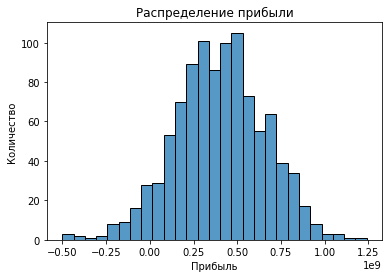

In [48]:
risks_and_profits(predictions_df, WELLS_TO_DEVELOP)

Средняя прибыль: 491390658.57
95%-й доверительный интервал от 93779593.56 до 904476668.87
Риск убытков: 0.90 %.


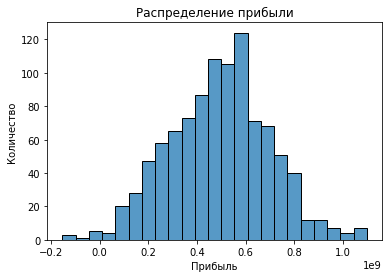

In [49]:
risks_and_profits(predictions_df_1, WELLS_TO_DEVELOP)

Средняя прибыль: 337860909.92
95%-й доверительный интервал от -190899524.88 до 826943305.45
Риск убытков: 10.30 %.


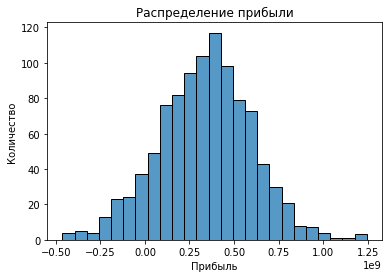

In [50]:
risks_and_profits(predictions_df_2, WELLS_TO_DEVELOP)

Вывод:

Модель predictions_df_1 кажется более выгодной с точки зрения средней прибыли и риска убытков.
Средняя прибыль: 491390658.57
95%-й доверительный интервал от 93779593.56 до 904476668.87
Риск убытков: 0.90 %.

Регионом с самым высоким риском является geo_data_2

Исходя из этих данных, рекомендуется выбрать для разработки скважин регион geo_data_1, так как он демонстрирует самую высокую ожидаемую прибыль из представленных регионов.

## Общий вывод:

Регион 1 является самым выгодным для разработки:
Средняя прибыль: 491390658.57
95%-й доверительный интервал от 93779593.56 до 904476668.87
Риск убытков: 0.90 %.

Рекомендуется выбрать для разработки скважин регион geo_data_1, так как он демонстрирует самую высокую ожидаемую прибыль из представленных регионов.

Рекомендации:
  провести более подробный анализ и выбор оптимального региона для разработки скважин, учитывая дополнительные факторы, такие как инфраструктура, логистика и экологические аспекты. А также выбирать скважины не по выгодности всего района, а по жирности каждой скважини.

## Чек-лист готовности проекта

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнен шаг 1: данные подготовлены
- [x]  Выполнен шаг 2: модели обучены и проверены
    - [x]  Данные корректно разбиты на обучающую и валидационную выборки
    - [x]  Модели обучены, предсказания сделаны
    - [x]  Предсказания и правильные ответы на валидационной выборке сохранены
    - [x]  На экране напечатаны результаты
    - [x]  Сделаны выводы
- [x]  Выполнен шаг 3: проведена подготовка к расчёту прибыли
    - [x]  Для всех ключевых значений созданы константы Python
    - [x]  Посчитано минимальное среднее количество продукта в месторождениях региона, достаточное для разработки
    - [x]  По предыдущему пункту сделаны выводы
    - [x]  Написана функция расчёта прибыли
- [x]  Выполнен шаг 4: посчитаны риски и прибыль
    - [x]  Проведена процедура *Bootstrap*
    - [x]  Все параметры бутстрепа соответствуют условию
    - [x]  Найдены все нужные величины
    - [x]  Предложен регион для разработки месторождения
    - [x]  Выбор региона обоснован